# Extended Wigner's friend scenario (with GHZ friends)

The extended Wigner's friend scenario (EWFS) with GHZ friends. Consider both "random" and "majority vote" approaches. Only consider the semi-Brukner inequality.

## Imports and setup

In [1]:
from typing import Optional

from enum import Enum
from collections import defaultdict
from datetime import datetime

import random
import numpy as np
import os
import pickle

from braket.circuits import Circuit, gates
from braket.tracking import Tracker

import qiskit
import qiskit_aer
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error
from qiskit.providers import Backend
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_distribution, plot_histogram
from qiskit.transpiler.passes import RemoveBarriers

from qiskit_braket_provider import (
    BraketLocalBackend,
    BraketProvider,
    to_braket,
    to_qiskit
)
from qiskit import (
    QuantumCircuit,
    QuantumRegister,
    transpile,

)
from qiskit_ionq import ionq_provider
from braket.devices import Devices
from braket.aws import AwsDevice, DirectReservation


DATA_PATH = os.path.join("data")

## Noise models

In [2]:
def depolarizing_noise_model(error: float = 0.01) -> NoiseModel:
    """Defines an depolarizing noise model with one-qubit.

    Args:
        error: One-qubit gate error rate (default 1%).
    Returns:
        Depolarizing noise model.
    """
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 1), ["u1", "u2", "u3"])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error, 2), "cx")
    return noise_model

In [3]:
def bitflip_model(p: float) -> NoiseModel:
    """Bitflip noise model with majority vote approach.

    Args:
        p: Probability to flip.
    Returns:
        Bit-flip noise model.
    """
    # Example error probabilities
    p_meas = p
    p_gate1 = p

    # QuantumError objects
    error_meas = pauli_error([("X", p_meas), ("I", 1 - p_meas)])
    error_gate1 = pauli_error([("X", p_gate1), ("I", 1 - p_gate1)])
    error_gate2 = error_gate1.tensor(error_gate1)

    # Add errors to noise model
    noise_bit_flip = NoiseModel()
    noise_bit_flip.add_all_qubit_quantum_error(error_meas, "measure")
    noise_bit_flip.add_all_qubit_quantum_error(error_gate1, ["u1", "u2", "u3"])
    noise_bit_flip.add_all_qubit_quantum_error(error_gate2, ["cx"])

    return noise_bit_flip

## Constants

In [4]:
# Settings for extended Wigner's friend scenario.
class Setting(Enum):
    PEEK = 1
    REVERSE_1 = 2
    REVERSE_2 = 3


# Observers for scenario are Alice and Bob.
class Observer(Enum):
    ALICE = 0
    BOB = 1

In [5]:
# Experiment settings (peek, reverse_1, and reverse_2).
PEEK = Setting.PEEK.value
REVERSE_1 = Setting.REVERSE_1.value
REVERSE_2 = Setting.REVERSE_2.value
SETTINGS = [PEEK, REVERSE_1, REVERSE_2]

# "Super"-observers (Alice and Bob).
ALICE = Observer.ALICE.value
BOB = Observer.BOB.value
OBSERVERS = [ALICE, BOB]

# Angles and beta term used for Alice and Bob measurement operators from arXiv:1907.05607.
# Note that despite the fact that degrees are used, we need to convert this to radians.
# ANGLES = {PEEK: np.deg2rad(168), REVERSE_1: np.deg2rad(0), REVERSE_2: np.deg2rad(118)}
# BETA = np.deg2rad(175)
ANGLES = {PEEK: np.deg2rad(40), REVERSE_1: np.deg2rad(230), REVERSE_2: np.deg2rad(310)}
BETA = np.deg2rad(220)

## Expectation values

In [6]:
def decode_results(results: dict, charlie_size: int, debbie_size: int = 1) -> dict[str, float]:
    """Take majority vote of measurement bit-strings."""
    decoded_results = {}

    # For each setting, there is a dictionary of measurement results.
    for setting in results:
        if setting == (PEEK, REVERSE_1) or setting == (PEEK, REVERSE_2):
            # Debbie's size is 1 because no PEEK setting
            debbie_size = 1

            setting_results = {}
            # Decode the keys for each measurement result of the setting.
            for k, v in results[setting].items():
                alice_friend, bob_friend = k[:charlie_size], k[-debbie_size:]

                alice_zero_count, bob_zero_count = alice_friend.count("0"), bob_friend.count("0")

                alice_decoding = "0" if alice_zero_count >= charlie_size // 2 + 1 else "1"
                bob_decoding = "0" if bob_zero_count >= 1 else "1"

                if alice_decoding + bob_decoding in setting_results.keys():
                    setting_results[alice_decoding + bob_decoding] += v
                else:
                    setting_results[alice_decoding + bob_decoding] = v
            decoded_results[setting] = setting_results
        else:
            decoded_results[setting] = results[setting]

    return decoded_results

In [7]:
def double_expect(settings: tuple[int, int], results: dict) -> float:
    """Expectation value of product of two operators."""
    probs = results[settings]
    # <AB> = P(00) - P(01) - P(10) + P(11)
    return probs.get("00", 0) - probs.get("01", 0) - probs.get("10", 0) + probs.get("11", 0)

## State preparation

In [8]:
def prepare_bipartite_system(qc: QuantumCircuit):
    """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
    qc.x(ALICE)
    qc.x(BOB)
    qc.h(ALICE)
    qc.cx(ALICE, BOB)

## CNOT ladder circuit

In [9]:
def cnot_ladder(qc: QuantumCircuit, observer: int, friend_qubit: int, friend_size: int, reverse: bool, internal_copy: bool):
    """CNOT ladder circuit (GHZ without Hadamard)."""
    if internal_copy:
        if reverse:
            for i in range(friend_size-1):
                qc.cx(friend_qubit + friend_size-2-i, friend_qubit+friend_size-1-i)
            qc.cx(observer, friend_qubit)
        else:
            qc.cx(observer, friend_qubit)
            for i in range(friend_size-1):
                qc.cx(friend_qubit+i, friend_qubit + i + 1)
    else:
        if reverse:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit+friend_size-1-i)
        else:
            for i in range(friend_size):
                qc.cx(observer, friend_qubit + i)

In [10]:
def cnot_ladder_random(qc: QuantumCircuit, observer: int, friend_qubit: int, friend_size: int):
    """CNOT ladder circuit (GHZ without Hadamard) for random strategy."""
    for i in range(friend_size):
        qc.cx(observer, friend_qubit + i)

## Circuit for extended Wigner's friend scenario

In [11]:
def ewfs_rotation(qc: QuantumCircuit, qubit: int, angle: float):
    qc.rz(-angle, qubit)
    qc.h(qubit)


def apply_setting(qc: QuantumCircuit,
                  strategy: str,
                  observer: int,
                  setting: int,
                  angle: float, 
                  observer_creg: list[int] | int,
                  friend_qubits: list[int],
                  friend_size: int):
    """Apply either the PEEK or REVERSE_1/REVERSE_2 settings."""
    if setting in [REVERSE_1, REVERSE_2]:
        if strategy == "majority_vote":
            cnot_ladder(qc, observer, friend_qubits[0], friend_size, reverse=True, internal_copy=True)
        elif strategy == "random":
            cnot_ladder_random(qc, observer, friend_qubits[0], friend_size)

        # For either REVERSE_1 or REVERSE_2, apply the appropriate angle rotations.
        # Note that in this case, the rotation should occur on the observer's qubit.
        if observer is ALICE:
            qc.h(ALICE)
            qc.rz(ANGLES[1], ALICE)

        if observer is BOB:
            qc.h(BOB)
            qc.rz((BETA - ANGLES[1]), BOB)
        ewfs_rotation(qc, observer, angle)


def apply_measurement(qc: QuantumCircuit,
                  strategy: str,
                  observer: int,
                  setting: int,
                  observer_creg: list[int] | int,
                  friend_qubits: list[int],
                  friend_size: int):
    if setting is PEEK:
        if strategy == "majority_vote":
            # Ask friend for the outcome.
            qc.measure(friend_qubits, observer_creg)
        elif strategy == "random":
            random_offset = random.randint(0, friend_size - 1)
            qc.measure(friend_qubits[0] + random_offset, observer)
    elif setting in [REVERSE_1, REVERSE_2]:
        if strategy == "majority_vote":
            qc.measure(observer, observer_creg)
        elif strategy == "random":
            qc.measure(observer, observer)


def ewfs(alice_setting: int,
         bob_setting: int,
         strategy: str,
         angles: list[float],
         beta: float,
         charlie_size: int,
         debbie_size: int = 1) -> QuantumCircuit:
    """Generate the circuit for extended Wigner's friend scenario."""
    # Define quantum registers
    alice_size, bob_size = 1, 1
    sys_size = alice_size + bob_size
    meas_size = 2

    alice, bob, charlie, debbie = [
        QuantumRegister(size, name=name)
        for size, name in zip([alice_size, bob_size, charlie_size, debbie_size], 
                              ["Alice's qubit", "Bob's qubit", "Charlie", "Debbie"])
    ]

    if strategy == "majority_vote":
        if (alice_setting == PEEK and bob_setting != PEEK):
            measurement = ClassicalRegister(charlie_size + 1, name="Measurement")
            alice_creg = list(range(charlie_size))
            bob_creg = charlie_size
        else:
            measurement = ClassicalRegister(meas_size, name="Measurement")
            alice_creg = 0
            bob_creg = 1
    elif strategy == "random":
        measurement = ClassicalRegister(sys_size, name="Measurement")
        alice_creg, bob_creg = 0, 0
    else:
        raise ValueError(f"Strategy: {strategy} is not defined.")

    # Create the Quantum Circuit with the defined registers
    qc = QuantumCircuit(alice, bob, charlie, debbie, measurement)

    charlie_qubits = list(range(sys_size, (sys_size + charlie_size)))
    debbie_qubits = list(range(sys_size + charlie_size, sys_size + (charlie_size + debbie_size)))

    # Prepare the bipartite quantum system
    prepare_bipartite_system(qc)

    # Rotations for measurement.
    ewfs_rotation(qc, ALICE, angles[1])
    ewfs_rotation(qc, BOB, beta - angles[1])

    # Apply the CNOT ladder for Alice-Charlie and Bob-Debbie
    if strategy == "majority_vote":
        cnot_ladder(qc, ALICE, charlie_qubits[0], charlie_size, reverse=False, internal_copy=True)
        cnot_ladder(qc, BOB, debbie_qubits[0], debbie_size, reverse=False, internal_copy=True)
    elif strategy == "random":
        cnot_ladder_random(qc, ALICE, charlie_qubits[0], charlie_size)
        cnot_ladder_random(qc, BOB, debbie_qubits[0], debbie_size)

    # Apply the settings for Alice/Charlie and Bob/Debbie
    apply_setting(qc, strategy, ALICE, alice_setting, angles[alice_setting], alice_creg, charlie_qubits, charlie_size)
    apply_setting(qc, strategy, BOB, bob_setting, (beta - angles[bob_setting]), bob_creg, debbie_qubits, debbie_size)

    # apply_measurement(qc, strategy, ALICE, alice_setting, alice_creg, charlie_qubits, charlie_size)
    # apply_measurement(qc, strategy, BOB, bob_setting, bob_creg, debbie_qubits, debbie_size)

    return qc

## Sanity checks (for majority vote approach)

In [12]:
# Print example circuit.
charlie_size = 1
setting = (PEEK, REVERSE_1)
qc = ewfs(setting[0], setting[1], "majority_vote", ANGLES, BETA, charlie_size, 1)
qc.measure_all()

# qc.draw("mpl", style="default")#.savefig("ewfs_majority_vote_peek_reverse_1.pdf")

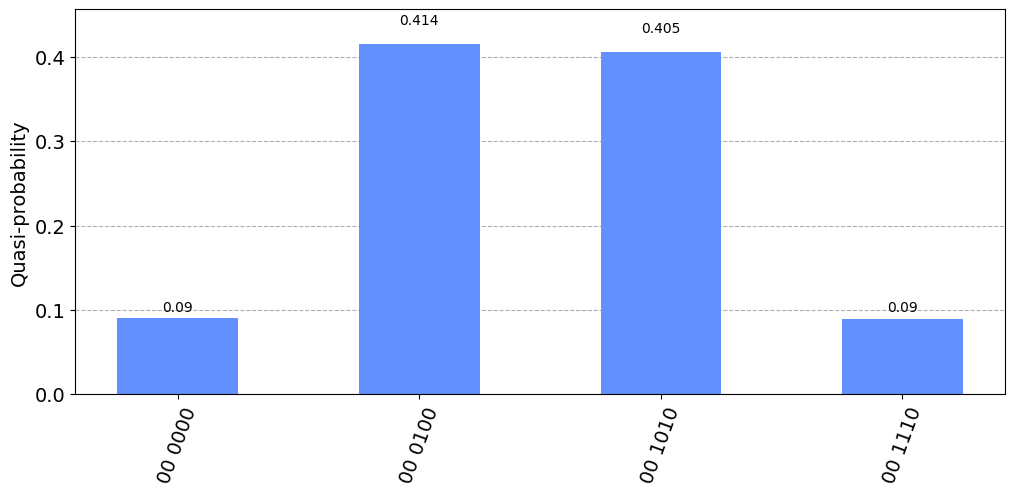

In [13]:
noise_bit_flip = bitflip_model(0.03)
simulator = AerSimulator()#(noise_model=noise_bit_flip)
transpiled_qc = transpile(qc, simulator, basis_gates=noise_bit_flip.basis_gates)

job = simulator.run(transpiled_qc, shots=10000)
result = job.result()

counts = result.get_counts()
probabilities = {key[::-1]: value / 10000 for key, value in counts.items()}

plot_histogram(probabilities, figsize=(12, 5))

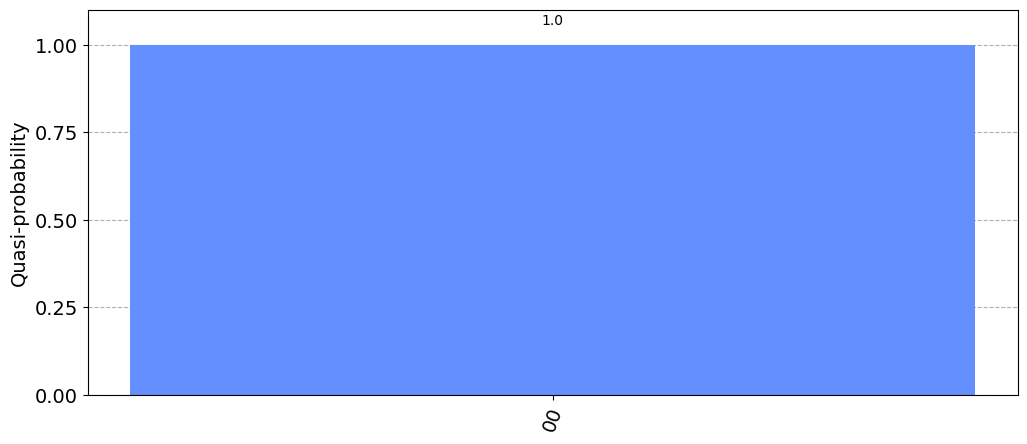

In [14]:
results = {setting: probabilities}
dec_res = decode_results(results, charlie_size)
probs = dec_res[setting]
plot_distribution(probs, figsize=(12, 5))

## File I/O

In [15]:
def save_data(
    results: dict,
    backend: Backend,
    friend_sizes: list[int],
    num_trials: int,
    shots: int,
    backend_name: Optional[str] = None,
    data_path: str = DATA_PATH,
):
    """Writes data to a file name format of `<MACHINE_NAME>_qubits_<NUM_QUBITS>_trial_<NUM_TRIALS>_shots_<NUM_SHOTS>`."""
    if backend_name is None:
        backend_name = backend.name

    for friend_size in friend_sizes:
        qubits = friend_size

        # If not output file name is given, use this format.
        output_file_name = f"{backend_name}_qubits_{qubits}_trial_{num_trials}_shots_{shots}.pickle"
        output_path = os.path.join(data_path, output_file_name)

        print(f"Writing data to: {output_path}")
        with open(output_path, "wb") as handle:
            pickle.dump(results, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [16]:
def load_experiments(
    machine_name: str,
    friend_sizes: list[int],
    num_trials: int,
    shots: int,
    strategy: str,
    data_path: str = DATA_PATH,
) -> dict:
    """Load experiments from multiple files."""
    all_results = {
        fs: {inequality: [] for inequality in ["semi_brukner"]}
        for fs in friend_sizes
    }

    for friend_size in friend_sizes:
        for trial in range(1, num_trials+1):
            with open(os.path.join(data_path, f"{machine_name}_qubits_{friend_size}_trial_{trial}_shots_{shots}.pickle"), "rb") as file:
                results = pickle.load(file)
            violations = compute_violations(results=results, charlie_size=friend_size, debbie_size=1, strategy=strategy)
            for key in violations:
                all_results[friend_size][key].append(violations[key])
    return all_results

## Inequalities

In [17]:
def compute_inequalities(results, verbose=False) -> dict[str, float]:
    """Compute the semi-Brukner inequalities."""
    A1B2 = double_expect((PEEK, REVERSE_1), results)
    A1B3 = double_expect((PEEK, REVERSE_2), results)

    A3B2 = double_expect((REVERSE_2, REVERSE_1), results)
    A3B3 = double_expect((REVERSE_2, REVERSE_2), results)

    # Eq. (18) from arXiv:1907.05607.
    semi_brukner = -A1B2 + A1B3 - A3B2 - A3B3 - 2

    if verbose:
        print(f"{semi_brukner=} -- is violated: {semi_brukner > 0}")

    return {"semi_brukner": semi_brukner}

In [18]:
def compute_violations(results: dict, charlie_size: int, debbie_size: int, strategy: str, verbose: bool = False) -> dict[str, float]:
    """Compute violation values based on strategy."""
    if strategy == "random":
        return compute_inequalities(results=results, verbose=verbose)
    elif strategy == "majority_vote":
        return compute_inequalities(decode_results(results=results, charlie_size=charlie_size, debbie_size=debbie_size), verbose=verbose)
    raise ValueError(f"Strategy: {strategy} not defined.")

## Experiment

#### Settings

In [19]:
# Experimental settings:
shots = 10_000
num_trials = 1
friend_sizes = range(1, 7)
strategy = "majority_vote"
# strategy = "random"
save = False

# Transpiler Backend settings:
provider = ionq_provider.IonQProvider() #token="SgVAVSugZ8aASqCSEWpjtOlpfTyUx8mM")
backend_name = "ionq_simulator"
backend = provider.get_backend(backend_name, gateset="native")

# Create timestamped directory to save results.
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
new_dir_name = f"{strategy}_{backend_name}_{timestamp}"
new_dir_path = os.path.join(DATA_PATH, new_dir_name)

if not os.path.exists(new_dir_path):
    os.makedirs(new_dir_path)

In [20]:
# helper function to extract the right bitstrings for postprocessing
# (aws seems to measure all qubits)
def translate_aws_results(results, charlie_size):
    res = {}
    for setting in results.keys():
        # print(setting)
        res_setting = {}
        for b in results[setting].keys():
            # print(b)
            if setting[0] == REVERSE_1 or setting[0] == REVERSE_2:
                b_setting = b[:2]
                res_setting[b_setting] = results[setting][b] + res_setting.get(b_setting, 0.0)
            if setting[0] == PEEK:
                b_setting = b[2:2+charlie_size] + b[1]
                res_setting[b_setting] = results[setting][b] + res_setting.get(b_setting, 0.0)

        res[setting] = res_setting
    return res

#### Create and run tasks

In [21]:
from braket.aws import AwsDevice, DirectReservation

device = AwsDevice(Devices.IonQ.Aria1)

# Uncomment Aria and comment out BraketLocalBackend when you want to run on Aria 1.
# aws_backend = BraketProvider().get_backend("Aria 1")
aws_backend = BraketLocalBackend()

# Uncomment to create tasks before or during the reservation
# reservation = DirectReservation(device=device, reservation_arn="arn:aws:braket:us-east-1:003146198539:reservation/6a8d07ad-aa7b-4cb2-b591-ee817553b019").start()

In [24]:
all_experiment_combos = [
    [PEEK, REVERSE_1],
    [PEEK, REVERSE_2],
    [REVERSE_2, REVERSE_1],
    [REVERSE_2, REVERSE_2],
]

# The tasks dictionary has a key that corresponds to the qubit 
# system size with an associated value of the task for that size.
tasks = defaultdict(int)

# Construct all circuits to be run over all qubit sizes.
for charlie_size in friend_sizes:
    circuits = {}

    # Create circuits for each EWFS setting.
    # Note, we remove barriers in the Qiskit circuit.
    for alice, bob in all_experiment_combos:
        circuits[(alice, bob)] = RemoveBarriers()(
            ewfs(alice, bob, strategy, ANGLES, BETA, charlie_size, 1)
        )

    # Transpile circuits to backend gateset.
    transpiled_circuits = { # Use IonQ Backend to transpile tasks
        k:  transpile(circuit, backend, optimization_level=0)
        for k, circuit in circuits.items()
    }

    # Run AWS task.
    print(f"Running task for {charlie_size=}")
    tasks[charlie_size] = aws_backend.run( # Use AWS Backend to run tasks
        list(transpiled_circuits.values()),
        shots=shots,
        verbatim=True,
    )
    print(f"Task with task ID: {task.job_id()}")

Running task for charlie_size=1
Task with task ID: 8742347e-0f1d-4110-bc58-46887beffa73;1941e50e-e394-4d20-bd49-d05309d5b2ee;d188bfc3-c5aa-4ce1-ad38-c069d28678a8;e0c5bd0b-aeed-454e-b748-307395b2952f
Running task for charlie_size=2
Task with task ID: 8742347e-0f1d-4110-bc58-46887beffa73;1941e50e-e394-4d20-bd49-d05309d5b2ee;d188bfc3-c5aa-4ce1-ad38-c069d28678a8;e0c5bd0b-aeed-454e-b748-307395b2952f
Running task for charlie_size=3
Task with task ID: 8742347e-0f1d-4110-bc58-46887beffa73;1941e50e-e394-4d20-bd49-d05309d5b2ee;d188bfc3-c5aa-4ce1-ad38-c069d28678a8;e0c5bd0b-aeed-454e-b748-307395b2952f
Running task for charlie_size=4
Task with task ID: 8742347e-0f1d-4110-bc58-46887beffa73;1941e50e-e394-4d20-bd49-d05309d5b2ee;d188bfc3-c5aa-4ce1-ad38-c069d28678a8;e0c5bd0b-aeed-454e-b748-307395b2952f
Running task for charlie_size=5
Task with task ID: 8742347e-0f1d-4110-bc58-46887beffa73;1941e50e-e394-4d20-bd49-d05309d5b2ee;d188bfc3-c5aa-4ce1-ad38-c069d28678a8;e0c5bd0b-aeed-454e-b748-307395b2952f
Runni

#### Post-processing tasks

In [23]:
results = {}
post_processed_results = {
    fs: {inequality: [] for inequality in ["semi_brukner"]}
    for fs in friend_sizes
}
for charlie_size, task in tasks.items():
    print(f"Processing task with task ID: {task.job_id()}")

    result = task.result()
    for key, count in zip(transpiled_circuits.keys(), result.get_counts()):
        probabilities = {k[::-1]: v / shots for k, v in count.items()}
        results[key] = probabilities
    print(f"Results: {results}")

    # Compute violations from result counts.
    violations = compute_violations(
        results=translate_aws_results(results, charlie_size),
        charlie_size=charlie_size,
        debbie_size=1,
        strategy=strategy,
        verbose=True
    )
    print(f"Violations: {violations}\n")

    for key in violations:
        post_processed_results[charlie_size][key].append(violations[key])

    # Save data after each trial of each charlie_size.
    if save:
        save_data(results=results,
                  backend=backend,
                  friend_sizes=[charlie_size],
                  num_trials=1,
                  shots=shots,
                  data_path=new_dir_path,
                  backend_name=backend_name)

Processing task with task ID: e716c261-c99f-4dca-a788-77a026a479b3;fd32071a-b6c8-41a9-b697-3c96b2519516;0a52c331-012b-4737-a33e-7cd2927acf5f;82e3f59b-ab47-49be-938c-b59b1ba28e9f
Results: {(1, 2): {'1010': 0.4124, '1110': 0.0897, '0100': 0.4063, '0000': 0.0916}, (1, 3): {'1110': 0.4097, '0100': 0.0943, '0000': 0.4027, '1010': 0.0933}, (3, 2): {'1000': 0.4365, '0100': 0.4468, '0000': 0.0593, '1100': 0.0574}, (3, 3): {'1000': 0.4455, '1100': 0.058, '0100': 0.4409, '0000': 0.0556}}
semi_brukner=0.8015999999999996 -- is violated: True
Violations: {'semi_brukner': 0.8015999999999996}

Processing task with task ID: 0eb5ceb4-e1ba-49b1-a5d2-c83b9b3d3927;1fdaf3c0-19eb-4dda-8479-b081d59d0c98;89fa7d56-96c3-4fa0-95fa-0f203fa8e43a;8fadf2c1-d238-4870-93b3-aae3b6b3884b
Results: {(1, 2): {'10110': 0.4067, '01000': 0.409, '00000': 0.092, '11110': 0.0923}, (1, 3): {'00000': 0.4161, '11110': 0.4031, '01000': 0.0938, '10110': 0.087}, (3, 2): {'01000': 0.4411, '10000': 0.4393, '00000': 0.0603, '11000': 0.05